In [ ]:
!pip install tensorflow-datasets

In [ ]:
import tensorflow_datasets as tfds

ds_train = tfds.load('emnist/letters', split='train')
ds_test = tfds.load('emnist/letters', split='test')

In [ ]:
builder = tfds.builder('emnist/letters')
builder.download_and_prepare()

print(builder.info)

In [ ]:
import matplotlib.pyplot as plt

import tensorflow_datasets as tfds

ds_train = tfds.load(
    'emnist/letters',
    split='train',
    as_supervised=True
)

for image, label in tfds.as_numpy(ds_train.take(1)):
    print(image.shape)
    print(label)

    plt.imshow(image.squeeze(), cmap='gray')
    plt.show()

In [ ]:
import tensorflow_datasets as tfds
import numpy as np

# Load dataset
train_ds = tfds.load('emnist/letters', split='train', as_supervised=True)
test_ds = tfds.load('emnist/letters', split='test', as_supervised=True)

# Convert training data
X_train = []
y_train = []

for image, label in tfds.as_numpy(train_ds):
    X_train.append(image)
    y_train.append(label)

X_train = np.array(X_train)
y_train = np.array(y_train)

# Convert testing data
X_test = []
y_test = []

for image, label in tfds.as_numpy(test_ds):
    X_test.append(image)
    y_test.append(label)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)
print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

In [ ]:

import matplotlib.pyplot as plt

index = 100

plt.imshow(X_train[index].squeeze(), cmap='gray')
plt.title(f"Label: {chr(y_train[index] + 64)}")
plt.axis('off')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

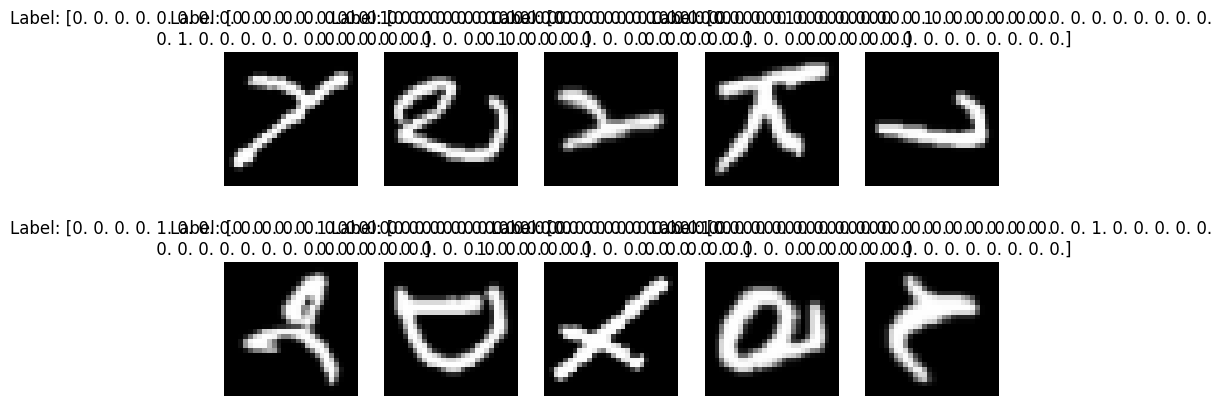

In [31]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i],cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
x_train=X_train.reshape(-1,28,28,1)
x_test=X_test.reshape(-1,28,28,1)

In [ ]:
print(X_train.shape)
print(X_test.shape)

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
y_train =to_categorical(y_train, 37)
y_test = to_categorical(y_test, 37)

In [22]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
model = Sequential()

#First Convolution layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
#First Pooling Layer
model.add(MaxPooling2D((2,2)))

#Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
#Second Pooling Layer
model.add(MaxPooling2D((2,2)))

#Flatten Layer
model.add(Flatten())

#Fully Connected Layer
model.add(Dense(128, activation='relu'))

#Dropout Layer
model.add(Dropout(0.5))

#Output Layer
model.add(Dense(37, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics =['accuracy'])

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 228,517 (892.64 KB)

 Trainable params: 228,517 (892.64 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history = model.fit(X_train, y_train, epochs =37, batch_size=32, validation_split=0.2)

Epoch 1/37
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.7457 - loss: 0.8322 - val_accuracy: 0.8960 - val_loss: 0.3222
Epoch 2/37
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.8590 - loss: 0.4432 - val_accuracy: 0.9130 - val_loss: 0.2702
Epoch 3/37
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8837 - loss: 0.3624 - val_accuracy: 0.9216 - val_loss: 0.2391
Epoch 4/37
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8965 - loss: 0.3171 - val_accuracy: 0.9251 - val_loss: 0.2265
Epoch 5/37
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9078 - loss: 0.2807 - val_accuracy: 0.9291 - val_loss: 0.2180
Epoch 6/37
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9142 - loss: 0.2563 - val_accuracy: 0.9346 - val_loss: 0.2124
Epoch 7/37
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9181 - loss: 0.2400 - val_accuracy: 0.9346 - val_loss: 0.2114
Epoch 8/37
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9226 - loss: 0.222

In [26]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


463/463 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9227 - loss: 0.3447
Test Loss: 0.344651997089386
Test Accuracy: 0.9227027297019958


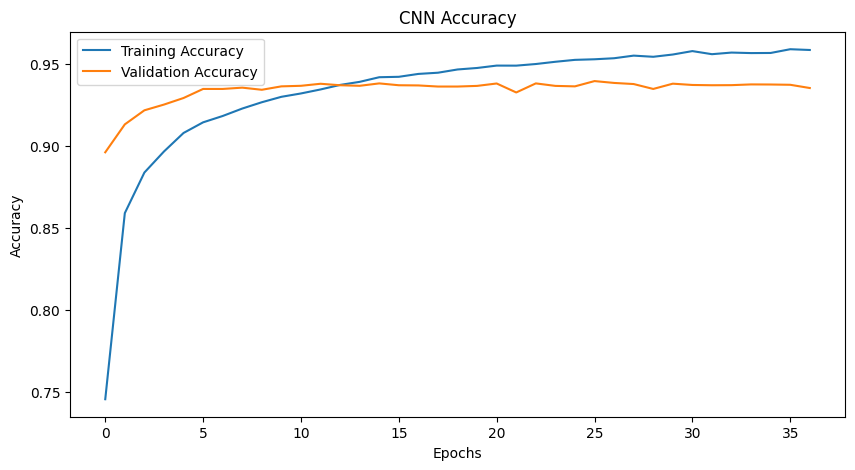

In [27]:
#Accuracy Curve
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy')
plt.legend()
plt.show()

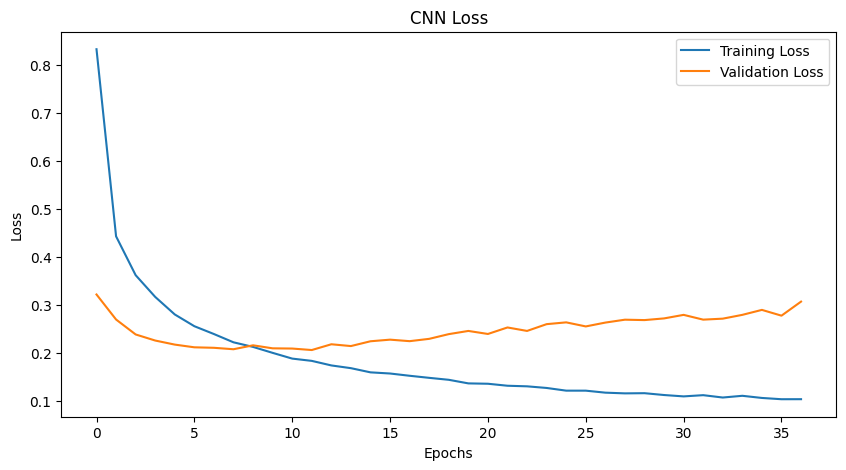

In [28]:
#Loss Curve
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Loss')
plt.legend()

Saving Screenshot 2026-06-05 121417.png to Screenshot 2026-06-05 121417.png


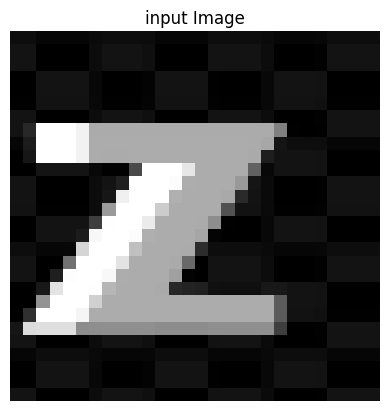

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted Letter: Y
Confidence Score 99.93656 %


In [30]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import cv2
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img =cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
#Resize the image
img = cv2.resize(img, (28,28))

#invert colors
img = 255 - img
#Normalize the image
img = img/255.0

#Display Image
plt.imshow(img, cmap='gray')
plt.title("input Image")
plt.axis('off')
plt.show()

#Reshape for CNN
img = img.reshape(1,28,28,1)

#Predict the image
prediction = model.predict(img)
predicted_class = np.argmax(prediction)

# Convert the predicted class to an EMNIST letter (assuming 1-26 for A-Z)
# Based on previous cells, adding 64 to a 1-based label converts it to ASCII uppercase.
predicted_letter = chr(predicted_class + 64)
print(f"Predicted Letter: {predicted_letter}")

#Print the confidence score
print("Confidence Score",np.max(prediction)*100,"%")